In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import os

RESULTS_DIR = '../results/grpo'
SMOOTH = 20  # rolling window for smoothing

RUNS = {
    'DAPO':    f'{RESULTS_DIR}/dapo_g16/train_log_dapo.csv',
    'Dr. GRPO': f'{RESULTS_DIR}/dr_grpo_g16/train_log_dr_grpo.csv',
}
COLORS = {'DAPO': '#e07b39', 'Dr. GRPO': '#3a86ff'}

In [10]:
dfs = {}
for name, path in RUNS.items():
    if os.path.exists(path):
        df = pd.read_csv(path)
        df = df.apply(pd.to_numeric, errors='coerce')
        dfs[name] = df
        print(f'{name}: {len(df)} steps, columns: {list(df.columns)}')
    else:
        print(f'{name}: file not found at {path}')

DAPO: 3871 steps, columns: ['step', 'epoch', 'loss', 'reward_mean', 'reward_std', 'frac_zero_std', 'completion_len', 'clip_ratio', 'entropy', 'lr']
Dr. GRPO: 3568 steps, columns: ['step', 'epoch', 'loss', 'reward_mean', 'reward_std', 'frac_zero_std', 'completion_len', 'clip_ratio', 'entropy', 'lr']


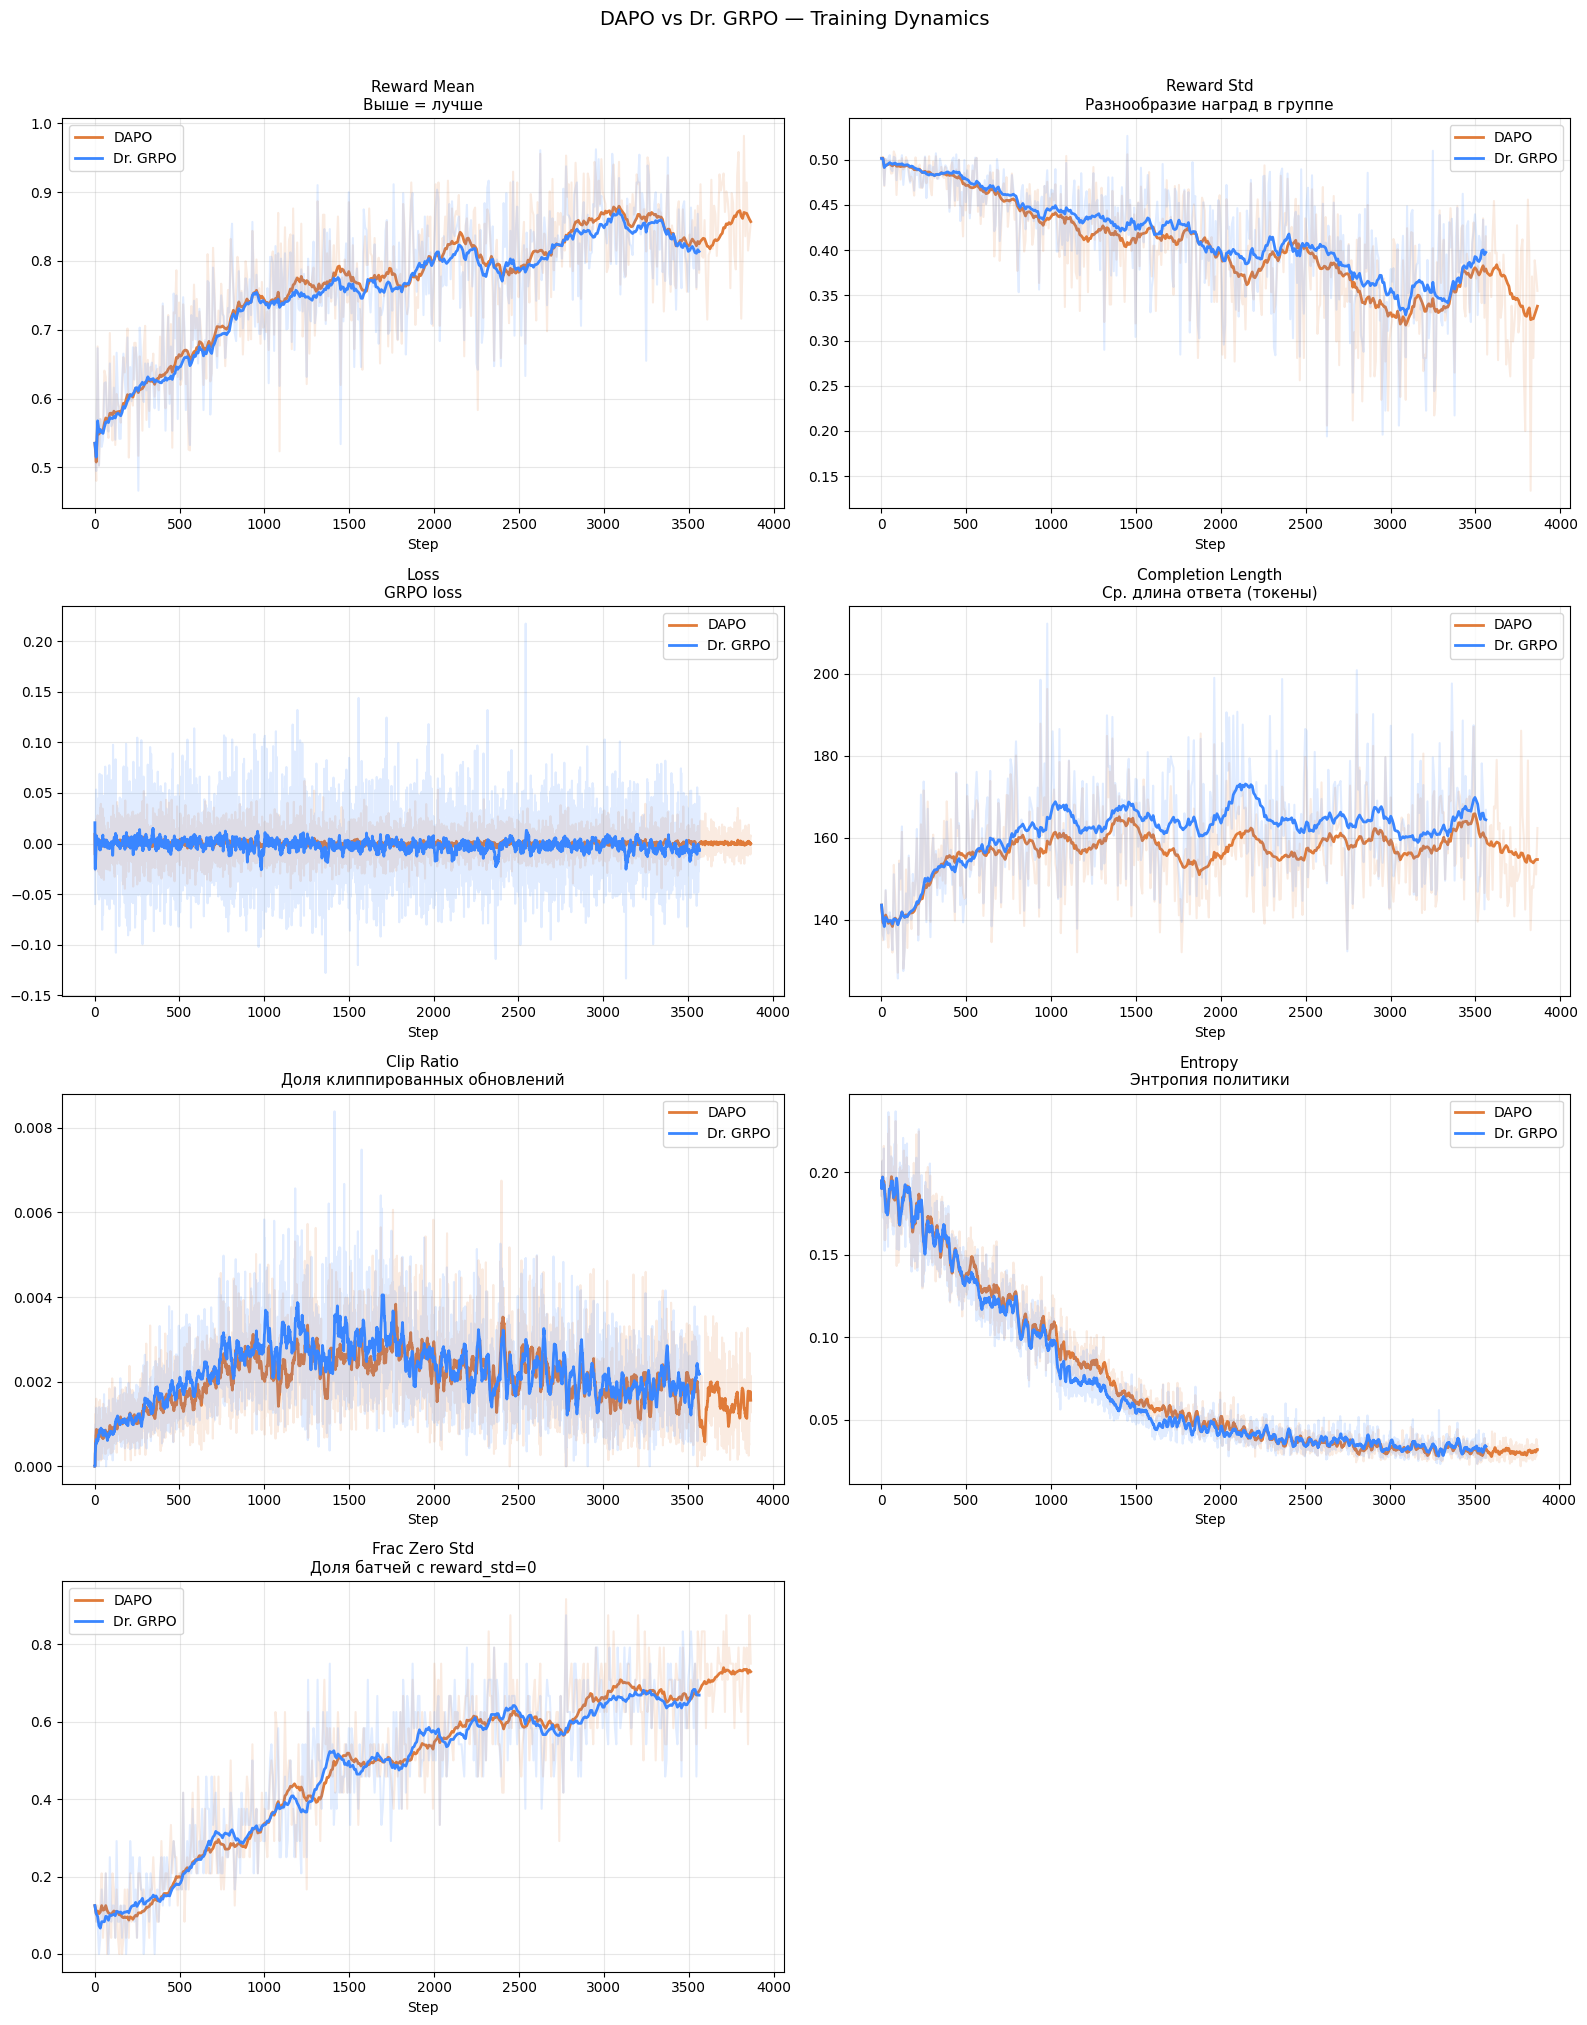

Saved to results/grpo/grpo_comparison.png


In [11]:
def smooth(s, w=SMOOTH):
    return s.rolling(w, min_periods=1).mean()

METRICS = [
    ('reward_mean',   'Reward Mean',         True,  'Выше = лучше'),
    ('reward_std',    'Reward Std',           False, 'Разнообразие наград в группе'),
    ('loss',          'Loss',                 False, 'GRPO loss'),
    ('completion_len','Completion Length',    False, 'Ср. длина ответа (токены)'),
    ('clip_ratio',    'Clip Ratio',           False, 'Доля клиппированных обновлений'),
    ('entropy',       'Entropy',              False, 'Энтропия политики'),
    ('frac_zero_std', 'Frac Zero Std',        False, 'Доля батчей с reward_std=0'),
]

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for ax_idx, (col, title, higher_better, note) in enumerate(METRICS):
    ax = axes[ax_idx]
    has_data = False
    for name, df in dfs.items():
        if col not in df.columns or df[col].isna().all():
            continue
        s = df[col].dropna()
        steps = df.loc[s.index, 'step']
        ax.plot(steps, s, alpha=0.15, color=COLORS[name])
        ax.plot(steps, smooth(s), label=name, color=COLORS[name], linewidth=2)
        has_data = True

    ax.set_title(f'{title}\n{note}', fontsize=11)
    ax.set_xlabel('Step')
    if has_data:
        ax.legend()
    ax.grid(alpha=0.3)

# Скрыть лишний subplot если метрик нечётное число
if len(METRICS) < len(axes):
    axes[-1].set_visible(False)

plt.suptitle('DAPO vs Dr. GRPO — Training Dynamics', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/grpo_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to results/grpo/grpo_comparison.png')

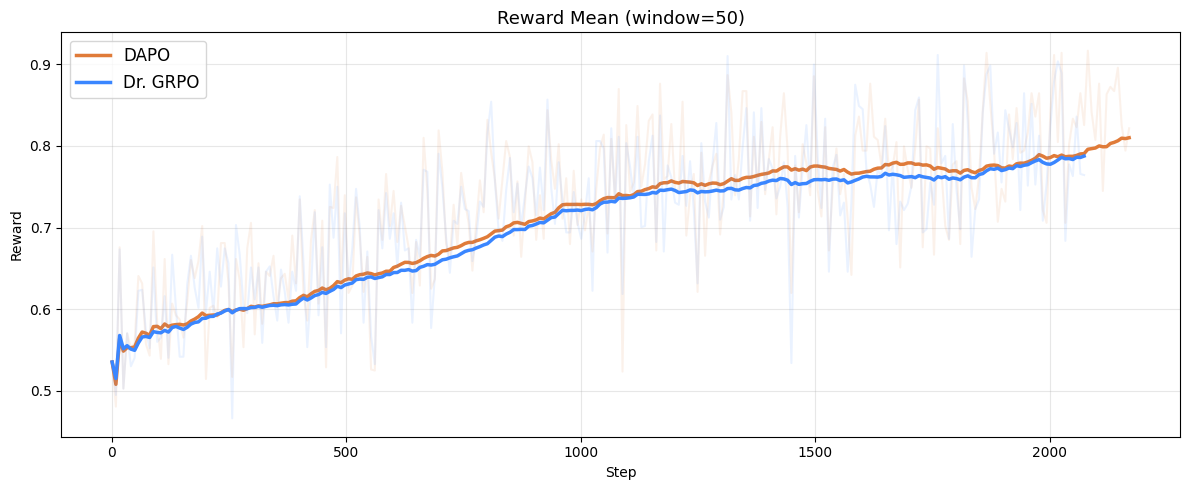

In [4]:
# Reward mean: крупно
fig, ax = plt.subplots(figsize=(12, 5))
for name, df in dfs.items():
    if 'reward_mean' not in df.columns:
        continue
    s = df['reward_mean'].dropna()
    steps = df.loc[s.index, 'step']
    ax.plot(steps, s, alpha=0.1, color=COLORS[name])
    ax.plot(steps, smooth(s, 50), label=name, color=COLORS[name], linewidth=2.5)

ax.set_title('Reward Mean (window=50)', fontsize=13)
ax.set_xlabel('Step')
ax.set_ylabel('Reward')
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/reward_comparison.png', dpi=150)
plt.show()

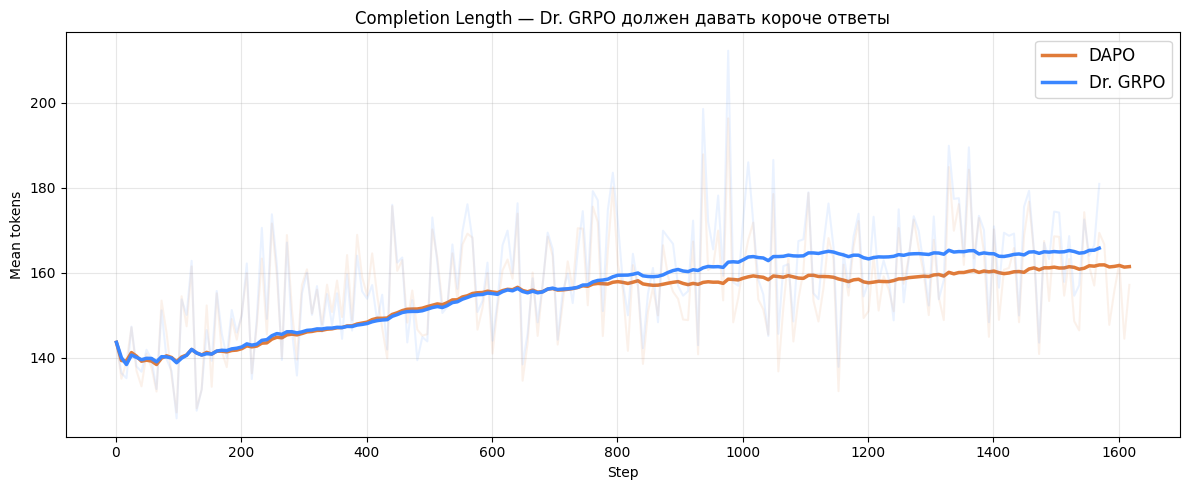

In [5]:
# Completion length: ключевой метрик для Dr. GRPO
fig, ax = plt.subplots(figsize=(12, 5))
for name, df in dfs.items():
    if 'completion_len' not in df.columns:
        continue
    s = df['completion_len'].dropna()
    steps = df.loc[s.index, 'step']
    ax.plot(steps, s, alpha=0.1, color=COLORS[name])
    ax.plot(steps, smooth(s, 50), label=name, color=COLORS[name], linewidth=2.5)

ax.set_title('Completion Length — Dr. GRPO должен давать короче ответы', fontsize=12)
ax.set_xlabel('Step')
ax.set_ylabel('Mean tokens')
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/completion_len_comparison.png', dpi=150)
plt.show()

In [6]:
# Итоговая таблица финальных значений
print(f'\n{"="*60}')
print('  Final stats (last 100 steps average)')
print(f'{"="*60}')
cols = ['reward_mean', 'reward_std', 'completion_len', 'clip_ratio', 'entropy', 'frac_zero_std']
for name, df in dfs.items():
    print(f'\n  {name}:')
    tail = df.tail(100)
    for col in cols:
        if col in df.columns and not tail[col].isna().all():
            val = tail[col].mean()
            print(f'    {col:<20}: {val:.4f}')


  Final stats (last 100 steps average)

  DAPO:
    reward_mean         : 0.7658
    reward_std          : 0.4186
    completion_len      : 157.5705
    clip_ratio          : 0.0026
    entropy             : 0.0583
    frac_zero_std       : 0.4931

  Dr. GRPO:
    reward_mean         : 0.7599
    reward_std          : 0.4266
    completion_len      : 166.7244
    clip_ratio          : 0.0029
    entropy             : 0.0552
    frac_zero_std       : 0.4826
